# Import packages

In [1]:
# Removed Drive import, not used anymore

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import time
from scipy.optimize import minimize, curve_fit
import urllib.request

# PINN for approximating Ray-tracing results

### Construct network

Key idea:

Input: a 9-dimensional vector describing the optical alignment state (scan angles + misalignment parameters like shifts and tilts).

Output: a single scalar — predicted fiber coupling efficiency (in log scale, later unnormalized).

This network is the digital twin: given a hypothetical mechanical/optical configuration, it predicts how much power couples into the fiber.

In [3]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class FiberCouplingNet(nn.Module):
    def __init__(self):
        super(FiberCouplingNet, self).__init__()
        self.fc1 = nn.Linear(9, 64)  # Input layer with 9 neurons (for 4 mirror angles, 5 collimation lens coordinates, xyz and tilt about xy) (expects normalised inputs)
        self.fc2 = nn.Linear(64, 1024) # Hidden layer
        self.fc3 = nn.Linear(1024, 1)  # Output layer with 1 neuron (for fiber coupling efficiency) (unnormalise to get to efficency)

    def forward(self, x):
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = self.fc3(x)
        return x


### Helper Functions

In [4]:
def getInputsOutputs(filename):
    data_file = np.load(filename)
    params = data_file["params"]
    thetas = data_file["thetas"]
    phis = data_file["phis"]
    Thetas, Phis = np.meshgrid(thetas, phis)
    Thetas = Thetas.flatten(); Phis = Phis.flatten()
    local_inputs = np.zeros((Thetas.shape[0], 13))
    local_inputs[:, 0] = Thetas
    local_inputs[:, 1] = Phis
    local_inputs[:, 8:13] = params
    return local_inputs, data_file["data"].flatten()

def normalize(y, y_min, y_max, scales=None):
    """
    Normalize a value to the range [-1, 1].

    Parameters:
    - y: The original value.
    - y_min: The minimum value of the original data.
    - y_max: The maximum value of the original data.

    Returns:
    - The normalized value.
    """
    normalised_data = np.zeros_like(y)
    if scales is not None:
        for _i, scale in enumerate(scales):
            if scale == 'log':
                # map the input value to a log range with y_min as the minimum value
                log_scaled = np.log10(y[:, _i]) # then linearly scale the log value to [-1, 1]
                linear_scaled = 2 * ((log_scaled - np.log10(y_min[_i])) / (np.log10(y_max[_i]) - np.log10(y_min[_i]))) - 1
            if scale == 'linear':
                linear_scaled = 2 * ((y[:, _i] - y_min[_i]) / (y_max[_i] - y_min[_i])) - 1

            normalised_data[:, _i] = linear_scaled
    else:
        normalised_data = 2 * ((y - y_min) / (y_max - y_min)) - 1
    return normalised_data

def unnormalize(y_norm, y_min, y_max, scales=None):
    """
    Unnormalize a value from the range [-1, 1] back to its original scale.

    Parameters:
    - y_norm: The normalized value.
    - y_min: The minimum value of the original data.
    - y_max: The maximum value of the original data.

    Returns:
    - The unnormalized (original) value.
    """
    y = np.zeros_like(y_norm)
    if scales is not None:
        for _i, scale in enumerate(scales):
            if scale == 'log':
                # map the input value to a log range with y_min as the minimum value
                log_scaled = ((y_norm[:, _i] + 1) / 2) * (np.log10(y_max[_i]) - np.log10(y_min[_i])) + np.log10(y_min[_i])
                # then linearly scale the log value to [y_min, y_max]
                linear_scaled = 10 ** log_scaled
            if scale == 'linear':
                linear_scaled = ((y_norm[:, _i] + 1) / 2) * (y_max[_i] - y_min[_i]) + y_min[_i]

            y[:, _i] = linear_scaled
    else:
        y = ((y_norm + 1) / 2) * (y_max - y_min) + y_min
    return y


def normalize_with_grad(y, y_min, y_max, scale=None):
    normalised_data = torch.zeros_like(y)

    if scale is None or scale == 'linear':
      normalised_data = 2 * ((y - y_min) / (y_max - y_min)) - 1

    if scale == 'log':
      y_log = torch.log10(y)
      min_log = torch.log10(y_min)
      max_log = torch.log10(y_max)
      normalised_data = 2*((y_log-min_log)/(max_log-min_log))-1

    return normalised_data.float()

def unnormalize_with_grad(y_norm, y_min, y_max, scale=None):
    y = torch.zeros_like(y_norm)

    if scale is None or scale == 'linear':
        y = ((y_norm + 1)/2) * (y_max - y_min) + y_min

    if scale == 'log':
      min_log = torch.log10(y_min)
      max_log = torch.log10(y_max)
      log_scaled = ((y_norm + 1)/2) * (max_log-min_log) + min_log
      linear_scaled = 10 ** log_scaled
      y = linear_scaled.float()

    return y


In [5]:
# Testing normalisation with grad
scale = 'log'

y_min = torch.tensor([1.0,1.0,1.0])
y_max = torch.tensor([10.0,10.0,10.0])

x = torch.tensor([1.0, 3.0, 5.0])
y = normalize_with_grad(x, y_min, y_max, scale)
z = unnormalize_with_grad(y, y_min, y_max, scale)

# print(x,y,z)
print(x)
x[0] = 3
print(x)
x[1] = torch.tensor([7])
print(x)

tensor([1., 3., 5.])
tensor([3., 3., 5.])
tensor([3., 7., 5.])


### Import data

In experiments we have uncertainties about 9 parameters $\mathbf{\theta}=(\phi_{1}, \psi_1, \phi_{2}, \psi_{2}, \delta x, \delta y, \delta z, \phi_x, \phi_y)$. We want to approximate the function $\eta=\eta(\mathbf{\theta})$, either through ray-tracing or a surrogate model. We can do this by first perform a large number of simulations covering this parameter space, and use this as training data for a multilayer-perceptron neural network. This is sort of our physics informed neural network; it is physics-informed because we use training data that is from simulators. The simulator completes one instance of $\mathbf{\theta}$ in about 1ms in Zemax, running 23 threads simultaneously. This allows us to generate about one million training examples in 20mins.

### Load Model

The raw data generated by Zemax is pretty large and is therefore trained separately. The parameter files and normalisation parameters are used here for better portability.

In [6]:
# specify location of the parameters for this NN
nn_parameters = "NN_parameter_data/fiber_coupling_model.pth"
normalisation_parameters = "NN_parameter_data/normalisation_parameters.npz"

device = "cpu"
model = FiberCouplingNet().to(device)
model.load_state_dict(torch.load(nn_parameters, map_location=torch.device(device)))
model.eval()  # Set the model to evaluation mode

# load normalisation parameters
norm_params = np.load(normalisation_parameters)
inputs_min = norm_params["inputs_min"]
inputs_max = norm_params["inputs_max"]
outputs_min = norm_params["outputs_min"]
outputs_max = norm_params["outputs_max"]

print(inputs_min) # np
print(inputs_max)
# print("---space---")
print(outputs_min)
print(outputs_max)

[-0.30206412 -0.20207836 -0.24366567 -0.22805994 -0.07237203 -0.06860425
 -0.18599459 -0.14738344 -0.14220149]
[0.21962818 0.23837144 0.21100417 0.29025098 0.07700438 0.09234082
 0.18653161 0.19266472 0.16596033]
0.001000010549638872
0.8024196170310478


# Examples getting predictions using sim-trained model

### Changing mirror angles

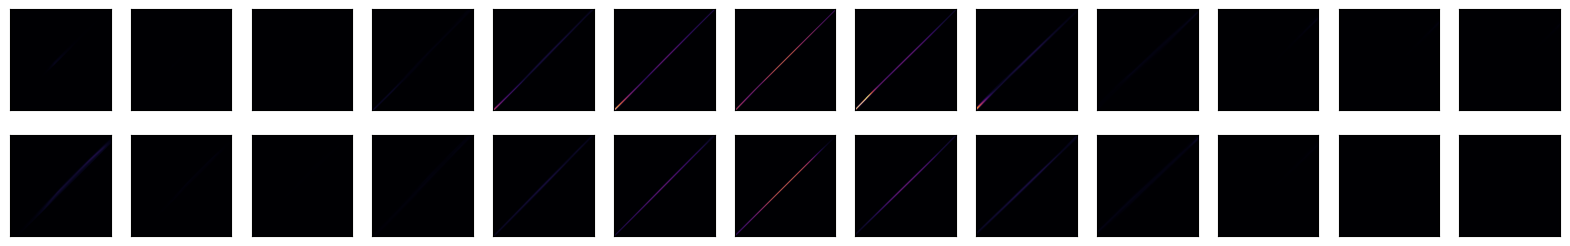

In [7]:
# New data for prediction
thetas = np.linspace(-1, 1, 200)
phis = np.linspace(-1, 1, 200)
Thetas, Phis = np.meshgrid(thetas, phis)
Thetas = Thetas.flatten(); Phis = Phis.flatten()
new_data = np.zeros((Thetas.shape[0], 9))
new_data[:, 2] = Thetas
new_data[:, 3] = Phis

shiftx = 0.000
shifty = 0.000
shiftz = 0.000
rotatex = 0.000
rotatey = 0.000

shiftzs = np.array([-1, -0.8, -0.5, -0.2, -0.1, -0.05, 0, 0.05, 0.1, 0.2, 0.5, 0.8, 1])

vmax = 0.1
fig, axs = plt.subplots(2, len(shiftzs), figsize=(20, 3))
for _i, shiftz in enumerate(shiftzs):
    for _j in range(2):
        new_data = np.zeros((Thetas.shape[0], 9))
        new_data[:, 4:] = [shiftx, shifty, shiftz, rotatex, rotatey]
        new_data[:, 0+_j] = Thetas
        new_data[:, 2+_j] = Phis
        new_data = normalize(new_data, inputs_min, inputs_max)
        # Example new input
        new_data = torch.from_numpy(new_data).to(device).to(torch.float32)
        prediction = model(new_data).cpu().detach().numpy()
        prediction = unnormalize(prediction, [outputs_min], [outputs_max], scales=['log'])

        ax = axs[_j, _i]
        im = ax.imshow(prediction.reshape(len(phis), len(thetas)), extent=[thetas.min(), thetas.max(), phis.min(), phis.max()], vmin=0, vmax=1, origin='lower', cmap="inferno")
        ax.set_xticks([])
        ax.set_yticks([])
    # add colorbar
    # cbar = ax.figure.colorbar(im, ax=ax)
    # cbar.set_label('Fiber coupling efficiency', rotation=-90, va="bottom")

plt.show()


### Defocusing

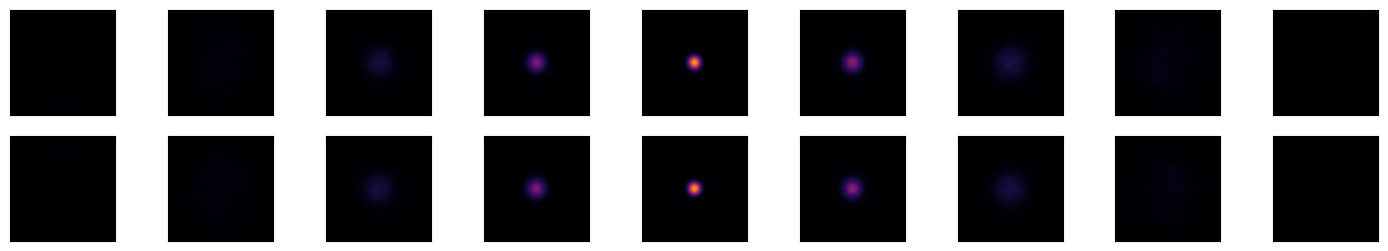

In [8]:
# New data for prediction
thetas = np.linspace(-.1, .1, 1000)
phis = np.linspace(-.1, .1, 1000)
Thetas, Phis = np.meshgrid(thetas, phis)
Thetas = Thetas.flatten(); Phis = Phis.flatten()
new_data = np.zeros((Thetas.shape[0], 9))

shiftx = 0.000
shifty = 0.000
shiftz = 0.000
rotatex = 0.000
rotatey = 0.000

shiftzs = np.array([-0.5, -0.2, -0.1, -0.05, 0, 0.05, 0.1, 0.2, 0.5])

vmax = 0.1
fig, axs = plt.subplots(2, len(shiftzs), figsize=(2*len(shiftzs), 3))
for _i, shiftz in enumerate(shiftzs):
    for _j, index in enumerate([0, 2]):
        new_data = np.zeros((Thetas.shape[0], 9))
        new_data[:, 4:] = [shiftx, shifty, shiftz, rotatex, rotatey]
        new_data[:, 0+index] = Thetas
        new_data[:, 1+index] = Phis
        new_data = normalize(new_data, inputs_min, inputs_max)
        # Example new input
        new_data = torch.from_numpy(new_data).to(device).to(torch.float32)
        prediction = model(new_data).cpu().detach().numpy()
        prediction = unnormalize(prediction, [outputs_min], [outputs_max], scales=['log'])

        ax = axs[_j, _i]
        im = ax.imshow(prediction.reshape(len(phis), len(thetas)), extent=[thetas.min(), thetas.max(), phis.min(), phis.max()], vmin=0, origin='lower', cmap="inferno", vmax=1)
        ax.set_xticks([])
        ax.set_yticks([])
    # add colorbar
    # cbar = ax.figure.colorbar(im, ax=ax)
    # cbar.set_label('Fiber coupling efficiency', rotation=-90, va="bottom")

plt.show()


## Why digital twin?

## Optimisation
At this point optimisation can be done already since we can find $\nabla_{\mathbf{\theta}}\eta(\mathbf{\theta})$ using auto-differentiation very quickly and use gradient-based optimisers to optimise the digital twin. We only have 9 inputs so the optimisation would be relatively straightforward.

I would recommend looking at this [paper](https://opg.optica.org/abstract.cfm?uri=ISA-2021-IF1D.6) to learn about autodiff for lens design and optimisation.

## Sensitivity analysis

We sometimes want to know how sensitive our cost function is to the input parameters; for example if one mirror drifts by 1 unit, how much does it affect the coupling efficiency. We can also use $\nabla_{\mathbf{\theta}}\eta$ to estimate this effect. This helps us to know which DOF we need to attach an actuator and which ones not to.

Using Principal Component Analysis (PCA), we can also transform the coordinate so that we can optimise along the most sensitive direction in the parameter space, not constrained by the physics DOFs that we define.

## Combining different sources of data
One example is in aerofoil design, where you could use coarse-grained simulations for a large number of models, fine-grained for a smaller subset of good designs, wind tunnel tests for a few candidatees and flight tests for one or two optimal designs. These tests generate data of different spatial density (flow at every point in simulation, versus wind speed sensors at a few places in flight tests). A large enough digital model allows one to incorporate these multifaceted datasets into one model.

# Process of building a digital twin

# Regression for Experimental Setup

In [9]:
# REPLACED CODE IN THIS WHOLE CELL

import torch.optim as optim

# ---------------------------------- Loading Data ---------------------------------- #

filenames = ["sample_data/TwoDMapOnTwoMirrorsLargeRangeFlexibleShaft_Run2_axis1.npz",
             "sample_data/TwoDMapOnTwoMirrorsLargeRangeFlexibleShaft_Run2_axis2.npz"]

# Format Data 1
data = np.load(filenames[0])
output1 = data["data"].flatten() * 20
angles1 = data["angles"]/360*0.5
phis1 = angles1
thetas1 = angles1        # no negation for axis1
Thetas1, Phis1 = np.meshgrid(thetas1, phis1)
Thetas1 = Thetas1.flatten(); Phis1 = Phis1.flatten()
assert Thetas1.shape[0] == output1.shape[0]

# Format Data 2
data = np.load(filenames[1])
output2 = data["data"].flatten() * 20
angles2 = data["angles"]/360*0.5
phis2 = angles2
thetas2 = -angles2       # negation for axis2 (different motor mounting)
Thetas2, Phis2 = np.meshgrid(thetas2, phis2)
Thetas2 = Thetas2.flatten(); Phis2 = Phis2.flatten()
assert Thetas2.shape[0] == output2.shape[0]

# Output Data
outputs = np.concatenate((output1, output2), axis=0)
filtered_index = np.where(outputs>0)[0]
filtered_outputs = outputs[filtered_index]
output_tensor = torch.from_numpy(filtered_outputs).to(device).to(torch.float32)
print(output_tensor.shape)

# Input Data
N = Thetas1.shape[0] + Thetas2.shape[0]
input_data = np.zeros((N, 9))
input_data[:Thetas1.shape[0], 0] = Thetas1
input_data[:Thetas1.shape[0], 2] = Phis1
input_data[Thetas2.shape[0]:, 1] = Thetas2
input_data[Thetas2.shape[0]:, 3] = Phis2
input_data = input_data[filtered_index, :]
input_tensor = torch.from_numpy(input_data).to(device).to(torch.float)
# ---------------------------------------------------------------------------------- #


# ---------------------------------- Training -------------------------------------- #

N_trials = 50 # prev: 5000
learning_rate = 1e-3   # was 0.0075 — reduced to prevent divergence
num_epochs = 1000
print_ratio = 1
print_inter = False
params = []

inputs_min_t = torch.tensor(inputs_min).to(device).to(torch.float32)
inputs_max_t = torch.tensor(inputs_max).to(device).to(torch.float32)
negative_t = torch.tensor([-1,-1,-1,-1,1,1,1,1,1,1])

# Informed initialization: grid-search NN optimum
with torch.no_grad():
    n = 20
    grid = torch.tensor(np.mgrid[
        inputs_min[0]:inputs_max[0]:n*1j,
        inputs_min[2]:inputs_max[2]:n*1j
    ].reshape(2,-1).T, dtype=torch.float32).to(device)
    test_inputs = torch.zeros(grid.shape[0], 9).to(device)
    test_inputs[:, 0] = grid[:, 0]
    test_inputs[:, 2] = grid[:, 1]
    normed = normalize_with_grad(test_inputs, inputs_min_t, inputs_max_t, scale='linear')
    preds = unnormalize_with_grad(model(normed), torch.tensor(outputs_min), torch.tensor(outputs_max), scale='log')
    best_idx = torch.argmax(preds)
    nn_opt_phi1 = grid[best_idx, 0].item()
    nn_opt_phi2 = grid[best_idx, 1].item()
    nn_max = preds[best_idx].item()

peak_idx1 = np.argmax(output1)
peak_angle1 = thetas1[peak_idx1 % len(thetas1)]
peak_idx2 = np.argmax(output2)
peak_angle2 = thetas2[peak_idx2 % len(thetas2)]

M11_init = peak_angle1 - nn_opt_phi1
M21_init = peak_angle1 - nn_opt_phi2
M12_init = peak_angle2 - nn_opt_phi1
M22_init = peak_angle2 - nn_opt_phi2
power_init = float(np.max(output1)) / nn_max

inputs_min_regr = np.append(inputs_min, power_init * 0.5)
inputs_max_regr = np.append(inputs_max, power_init * 2.0)
assert inputs_min_regr.shape[0] == 10
assert inputs_max_regr.shape[0] == 10
inputs_min_regr_t = torch.tensor(inputs_min_regr).to(device).to(torch.float32)
inputs_max_regr_t = torch.tensor(inputs_max_regr).to(device).to(torch.float32)

print(f"NN optimum: phi1={nn_opt_phi1:.3f}, phi2={nn_opt_phi2:.3f}, max_eff={nn_max:.3f}")
print(f"Init: M11={M11_init:.3f}, M12={M12_init:.3f}, M21={M21_init:.3f}, M22={M22_init:.3f}, power={power_init:.1f}")

# Random guesses, first one is the informed start
guesses = np.random.uniform(inputs_min_regr, inputs_max_regr, (N_trials, 10))
guesses[0] = np.array([M11_init, M12_init, M21_init, M22_init, 0., 0., 0., 0., 0., power_init])
guesses_tensor = [torch.from_numpy(g).to(device).to(torch.float32) for g in guesses]

best_guess_i = 0
best_cost = 1e100

for i, guess in enumerate(guesses_tensor):

    guess.requires_grad = True
    optimizer = optim.Adam([guess], lr=learning_rate)

    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=num_epochs, eta_min=1e-5)

    for step in range(num_epochs):

        input_params = guess * negative_t
        inputs = input_tensor.clone().to(device).to(torch.float) + input_params[:9]
        inputs = torch.clamp(inputs, inputs_min_t, inputs_max_t)   # keep inside NN training domain
        inputs = normalize_with_grad(inputs, inputs_min_t, inputs_max_t, scale='linear')

        prediction = model(inputs)
        prediction = unnormalize_with_grad(prediction, torch.tensor(outputs_min), torch.tensor(outputs_max), scale='log')
        predicted_power = torch.flatten(prediction) * input_params[9]

        ssr = torch.sum((predicted_power - output_tensor)**2)
        ssr.backward()
        torch.nn.utils.clip_grad_norm_([guess], max_norm=1.0)   # prevent gradient explosion
        optimizer.step()
        scheduler.step()
        guess.data.clamp_(inputs_min_regr_t, inputs_max_regr_t)  # in-place clamp (original was a no-op)
        optimizer.zero_grad()

        if i == 0 and (step + 1) % 100 == 0:
          print(f"  Trial 1, step {step+1}: SSR={ssr.item():.2f}, max_power={predicted_power.max().item():.4f}")

        if ((step + 1) % (num_epochs / print_ratio) == 0 and print_inter):
            print(f'Trial: {i+1} Step [{step+1}/{num_epochs}], SSR: {ssr.item():.2f}')

        if (step + 1 == num_epochs):
            params.append((guess, ssr))
            if ssr < best_cost:
                best_guess_i = i
                best_cost = ssr

# ------------------------------------------------------------------------------------ #


# ---------------------------------- Analyzing Data ---------------------------------- #
best_guess, best_cost = params[best_guess_i]
M11_0, M12_0, M21_0, M22_0, shiftx, shifty, shiftz, rotatex, rotatey, input_power = best_guess.detach().numpy()

print(f'best_loss: {best_cost}')
print(f'best_guess: {best_guess}')
# ------------------------------------------------------------------------------------- #


torch.Size([1393])
NN optimum: phi1=-0.027, phi2=-0.028, max_eff=0.800
Init: M11=-0.028, M12=-0.138, M21=-0.027, M22=-0.137, power=29.8
  Trial 1, step 100: SSR=166671.78, max_power=19.1185
  Trial 1, step 200: SSR=164946.84, max_power=17.9576
  Trial 1, step 300: SSR=164671.34, max_power=17.9868
  Trial 1, step 400: SSR=164604.48, max_power=18.0329
  Trial 1, step 500: SSR=165539.12, max_power=18.8177
  Trial 1, step 600: SSR=164818.38, max_power=18.8890
  Trial 1, step 700: SSR=164624.50, max_power=18.3145
  Trial 1, step 800: SSR=164307.62, max_power=18.1604
  Trial 1, step 900: SSR=164290.38, max_power=18.1914
  Trial 1, step 1000: SSR=164273.94, max_power=18.2114
best_loss: 124558.1875
best_guess: tensor([-6.4638e-02,  2.3837e-01,  6.5353e-02,  2.7584e-01, -1.6795e-03,
         2.7809e-02, -5.4696e-02,  8.0575e-02, -7.2904e-02,  4.9339e+01],
       requires_grad=True)


In [10]:

# I added this cell
with torch.no_grad():
    test_input = torch.tensor([[0.1, 0.1, 0.1, 0.1, 0., 0., 0., 0., 0.]], dtype=torch.float32).to(device)
    test_norm = normalize_with_grad(test_input, inputs_min_t, inputs_max_t, scale='linear')
    test_pred = model(test_norm)
    test_out = unnormalize_with_grad(test_pred, torch.tensor(outputs_min), torch.tensor(outputs_max), scale='log')
    print(f"NN at optimum: {test_out}")
    print(f"outputs_min: {outputs_min}, outputs_max: {outputs_max}")


NN at optimum: tensor([[0.7800]])
outputs_min: 0.001000010549638872, outputs_max: 0.8024196170310478


In [11]:
x = normalize_with_grad(best_guess[:9], inputs_min_t, inputs_max_t, scale='linear')
y = unnormalize_with_grad(x, inputs_min_t, inputs_max_t, scale='linear')
print(best_guess[:9])
print(x)
print(y)

tensor([-0.0646,  0.2384,  0.0654,  0.2758, -0.0017,  0.0278, -0.0547,  0.0806,
        -0.0729], grad_fn=<SliceBackward0>)
tensor([-0.0898,  1.0000,  0.3593,  0.9444, -0.0535,  0.1981, -0.2951,  0.3407,
        -0.5503], grad_fn=<SubBackward0>)
tensor([-0.0646,  0.2384,  0.0654,  0.2758, -0.0017,  0.0278, -0.0547,  0.0806,
        -0.0729], grad_fn=<AddBackward0>)


In [12]:
print(f'best_loss: {best_cost}')
print(f'best_guess: {best_guess[:9]}')
print(inputs_min_t)
print(inputs_max_t)

best_loss: 124558.1875
best_guess: tensor([-0.0646,  0.2384,  0.0654,  0.2758, -0.0017,  0.0278, -0.0547,  0.0806,
        -0.0729], grad_fn=<SliceBackward0>)
tensor([-0.3021, -0.2021, -0.2437, -0.2281, -0.0724, -0.0686, -0.1860, -0.1474,
        -0.1422])
tensor([0.2196, 0.2384, 0.2110, 0.2903, 0.0770, 0.0923, 0.1865, 0.1927, 0.1660])


# Optimization of Mirror angles




In [13]:
import torch.optim as optim

# Parameters restated for convenience
print("--- Expiremental Parameters ---")
print(M11_0, M12_0, M21_0, M22_0, shiftx, shifty, shiftz, rotatex, rotatey)
# Hyper Parameters
K_trials = 1000
learning_rate = 0.01
num_epochs = 100
print_ratio = 2
print_inter = True
params_e = []

# Initialize the tensor for the parameters to be optimized
guesses = np.random.uniform(inputs_min, inputs_max, (K_trials, 9))
guesses[:, 4:] = [shiftx, shifty, shiftz, rotatex, rotatey]
guesses_tensor = [torch.from_numpy(guess).to(device).to(torch.float32) for guess in guesses]

# Loop through guesses
best_guess_i_e = 0
best_cost_e = 1e100

for i, guess in enumerate(guesses_tensor):

  # Initialize optimizer
  guess.requires_grad = True
  optimizer = optim.Adam([guess], lr=learning_rate)

  # Training Loop
  for step in range(num_epochs):

      # Normalize the inputs
      input = normalize_with_grad(guess, inputs_min_t, inputs_max_t, scale='linear')

      # Forward pass
      output = model(input)
      eff = unnormalize_with_grad(output, torch.tensor(outputs_min), torch.tensor(outputs_max), scale='log')

      # We want to maximize the output, so we take the negative of the output as the loss
      cost = -eff

      # Backward pass
      cost.backward()

      # Update the input parameters
      guess.grad[4:] = 0 # Only optimize on first 4 parameters, so set grad of rest to zero
      optimizer.step()

      # Zero the gradients
      guess.clamp(inputs_min_t, inputs_max_t)
      optimizer.zero_grad()

      # Stop Trial if reached dead zone
      if(eff < 0.01 and step > 3):
        # print(f'Trial: {i+1} Step [{step+1}/{num_epochs}], Efficency: {eff}') # ***
        params_e.append((guess, cost))
        break

      # Intermediatery
      if ((step + 1) % (num_epochs / print_ratio) == 0 and print_inter): print(f'Trial: {i+1}, Step [{step+1}/{num_epochs}], Cost: {cost}, Efficency: {eff}')

      # On Final Optimization
      if (step + 1 == num_epochs):
        params_e.append((guess, cost))
        if(cost < best_cost_e):
          best_guess_i_e = i
          best_cost_e = cost

# Added to results
best_guess_e, best_cost_e = params_e[best_guess_i_e]

print(f'trial: {best_guess_i_e+1}')
print(f'best_loss: {best_cost_e}')
print(f'best_guess: {best_guess_e}')








# Print the optimized input parameters
# print("\n\n\n-----Final-----\n\nOptimized input parameters:\n", params_to_optimize)

# final_params = params_to_optimize.detach().numpy()
# final_unnormal_params = unnormalize(final_params, inputs_min, inputs_max)

# print("\n\n\n-----Final-----\n")
# print("Optimized unn parameters:\n", final_unnormal_params)

# print("\n\nMaxes\n")
# print(inputs_min)
# print(inputs_max)

--- Expiremental Parameters ---
-0.06463777 0.23837143 0.06535263 0.275844 -0.0016795045 0.027809447 -0.05469569 0.080575496 -0.07290371
Trial: 2, Step [50/100], Cost: tensor([-0.2651], grad_fn=<NegBackward0>), Efficency: tensor([0.2651], grad_fn=<PowBackward2>)
Trial: 2, Step [100/100], Cost: tensor([-0.2793], grad_fn=<NegBackward0>), Efficency: tensor([0.2793], grad_fn=<PowBackward2>)
Trial: 5, Step [50/100], Cost: tensor([-0.3026], grad_fn=<NegBackward0>), Efficency: tensor([0.3026], grad_fn=<PowBackward2>)
Trial: 5, Step [100/100], Cost: tensor([-0.2875], grad_fn=<NegBackward0>), Efficency: tensor([0.2875], grad_fn=<PowBackward2>)
Trial: 17, Step [50/100], Cost: tensor([-0.2738], grad_fn=<NegBackward0>), Efficency: tensor([0.2738], grad_fn=<PowBackward2>)
Trial: 17, Step [100/100], Cost: tensor([-0.2719], grad_fn=<NegBackward0>), Efficency: tensor([0.2719], grad_fn=<PowBackward2>)
Trial: 32, Step [50/100], Cost: tensor([-0.2283], grad_fn=<NegBackward0>), Efficency: tensor([0.2283],

In [14]:
print(best_guess)

print("\n\nMaxes\n")
print(inputs_min_t)
print(inputs_max_t)



print((best_guess_e >= inputs_min_t))
print((best_guess_e <= inputs_max_t))

tensor([-6.4638e-02,  2.3837e-01,  6.5353e-02,  2.7584e-01, -1.6795e-03,
         2.7809e-02, -5.4696e-02,  8.0575e-02, -7.2904e-02,  4.9339e+01],
       requires_grad=True)


Maxes

tensor([-0.3021, -0.2021, -0.2437, -0.2281, -0.0724, -0.0686, -0.1860, -0.1474,
        -0.1422])
tensor([0.2196, 0.2384, 0.2110, 0.2903, 0.0770, 0.0923, 0.1865, 0.1927, 0.1660])
tensor([ True,  True, False,  True,  True,  True,  True,  True,  True])
tensor([True, True, True, True, True, True, True, True, True])


In [15]:

optimal = torch.tensor([0.1, 0.1, 0.1, 0.1, 0.0, 0.0, 0.0, 0.0, 0.0])

input = normalize_with_grad(optimal, inputs_min_t, inputs_max_t, scale='linear')
output = model(input)
eff = unnormalize_with_grad(output, torch.tensor(outputs_min), torch.tensor(outputs_max), scale='log')
print(eff)

tensor([0.7800], grad_fn=<PowBackward2>)


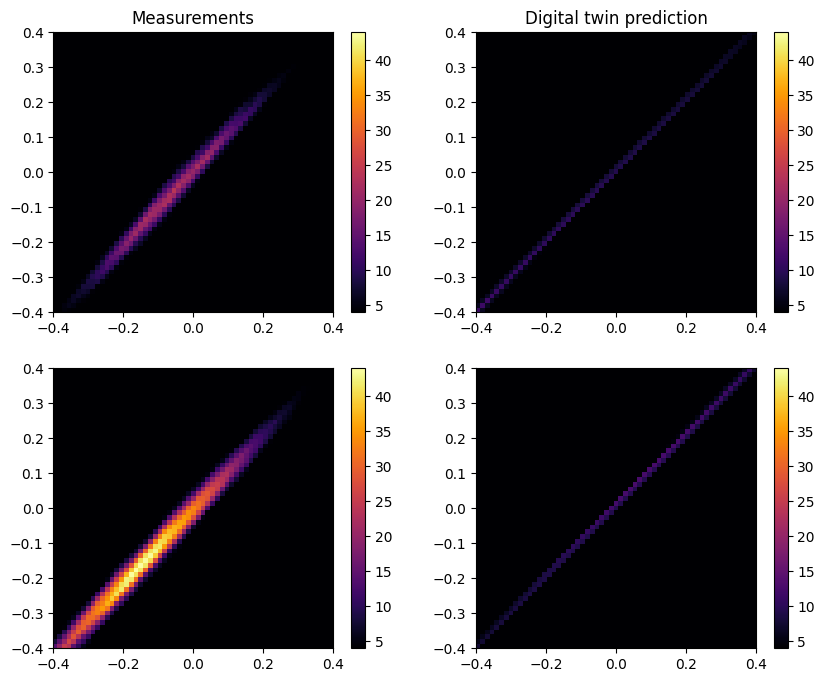

In [16]:
# load data
data = np.load(filenames[0])
result1 = data["data"]*20
thetas1 = data["angles"]/360*0.5
phis1 = thetas1
# thetas1 = -thetas1 # Commented this out
Thetas1, Phis1 = np.meshgrid(thetas1, phis1)
Thetas1 = Thetas1.flatten(); Phis1 = Phis1.flatten()

data = np.load(filenames[1])
result2 = data["data"]*20
thetas2 = data["angles"]/360*0.5
phis2 = thetas2
thetas2 = -thetas2
Thetas2, Phis2 = np.meshgrid(thetas2, phis2)
Thetas2 = Thetas2.flatten(); Phis2 = Phis2.flatten()

vmax = 2.2 * 20
vmin = 0.2 * 20
fig, axs = plt.subplots(2, 2, figsize=(10, 8))
im = axs[0, 0].imshow(result1, extent=[thetas1[0], thetas1[-1], phis1.min(), phis1.max()], origin='lower', cmap="inferno", vmin=vmin, vmax=vmax)
cbar = fig.colorbar(im, ax=axs[0, 0])
axs[0, 0].set_xlim(-0.4, 0.4)
axs[0, 0].set_ylim(-0.4, 0.4)

im = axs[1, 0].imshow(result2, extent=[thetas2[0], thetas2[-1], phis2.min(), phis2.max()], origin='lower', cmap="inferno", vmin=vmin, vmax=vmax)
cbar = fig.colorbar(im, ax=axs[1, 0])
axs[1, 0].set_xlim(-0.4, 0.4)
axs[1, 0].set_ylim(-0.4, 0.4)
axs[0, 0].set_title("Measurements")
# M11_0 = 0.320
# M12_0 = -0.020
# M21_0 = 0.520
# M22_0 = 0.000

# I deleted the zero assignments for the Mxx_0

# I deleted the zero assignments for the shift & rotate vars below

# shiftx = 0.000
# shifty = 0.002
# shiftz = -0.350
# rotatex = -0.100
# rotatey = 0.000
# input_power = 20 # I commented this out


# New data for prediction
N = Thetas1.shape[0]
new_data = np.zeros((N, 9))
new_data[:, 4:] = [shiftx, shifty, shiftz, rotatex, rotatey]
new_data[:Thetas1.shape[0], 0] = Thetas1 - M11_0
new_data[:Thetas1.shape[0], 1] = -M12_0
new_data[:Thetas1.shape[0], 2] = Phis1 - M21_0
new_data[:Thetas1.shape[0], 3] = -M22_0

pred_1 = model(torch.from_numpy(normalize(new_data, inputs_min, inputs_max)).to(device).to(torch.float32)).cpu().detach().numpy()
pred_1 = unnormalize(pred_1, [outputs_min], [outputs_max], scales=['log']) * input_power
im = axs[0, 1].imshow(pred_1.reshape(len(phis1), len(thetas1)), extent=[thetas1[0], thetas1[-1], phis1.min(), phis1.max()], origin='lower', cmap="inferno", vmin=vmin, vmax=vmax)
cbar = fig.colorbar(im, ax=axs[0, 1])
axs[0, 1].set_xlim(-0.4, 0.4)
axs[0, 1].set_ylim(-0.4, 0.4)

N = Thetas2.shape[0]
new_data = np.zeros((N, 9))
new_data[:, 4:] = [shiftx, shifty, shiftz, rotatex, rotatey]
new_data[:Thetas2.shape[0], 0] = -M11_0
new_data[:Thetas2.shape[0], 1] = Thetas2 - M12_0
new_data[:Thetas2.shape[0], 2] = - M21_0
new_data[:Thetas2.shape[0], 3] = Phis2 - M22_0

pred_2 = model(torch.from_numpy(normalize(new_data, inputs_min, inputs_max)).to(device).to(torch.float32)).cpu().detach().numpy()
pred_2 = unnormalize(pred_2, [outputs_min], [outputs_max], scales=['log']) * input_power
im = axs[1, 1].imshow(pred_2.reshape(len(phis2), len(thetas2)), extent=[thetas2[0], thetas2[-1], phis2.min(), phis2.max()], origin='lower', cmap="inferno", vmin=vmin, vmax=vmax)
axs[1, 1].set_xlim(-0.4, 0.4)
axs[1, 1].set_ylim(-0.4, 0.4)
axs[0, 1].set_title("Digital twin prediction")
cbar = fig.colorbar(im, ax=axs[1, 1])


# Alignment


### Naive alignment
One can start off with brute force alignment, using numerical optimisation that is robust against measurement noise, for example [CMA](https://en.wikipedia.org/wiki/CMA-ES) which has also been implemented in python. Or using some of the built-in optimisers such as Nelder-Mead. These algorithms does a random search and are therefore not very efficient if needed to run with high dimensions and on the physical hardware.

### Model-based optimisation
The workflow for model-based approach, involves calibrating a digitial twin first by taking a bunch of measurements as have been done in the previous sections in this notebook. Then using efficient simulators we can try to match the physical parameters in the simulator to the actual set-up. This matching process may not be trivial. Then using numerical optimisation on the digital twin, we can get a coarse-grained optimisation very efficiently.

#### Open questions
* What is the most efficient way to sample the physical system? (Think about the Fisher information)
* Once you know the optimum using the calibrated digital twin, you would implement this optimal configuration on hardware. In this process, more data would be gathered. How would you incorporate new data into the existing digital twin? (Think about Bayesian theorem and posterior distributions)

#### Tasks
1. Calibrate the digital twin using existing data and verify by taking more measurements. Do you see limitations with the digital-physical mapping?
2. Find the optimal point (best coupling efficiency) of this digital twin.
3. (Long-term) build a framework to update the digital twin as the system is slowly varying in time.

# Remote alignment and physical lab on the cloud

The lab instrumentation has been set such that all actuators and sensors can bee accessed by requesting from an URL. The IP addresses can be obtained by querying the master ip address to MAC address mapping server at
18.25.23.104
This IP address might change over time. Here is a series of instructions for accessing the devices.

You can also check the online status of various devices [here](http://18.25.23.104:8080/). At the moment the names are a bit chaotic.

In [17]:
import requests
import json

def get_json_file(server_ip):
    url = f"http://{server_ip}:8080/json-file"
    response = requests.get(url)

    if response.status_code == 200:
        json_data = response.json()
        print("JSON Data:", json_data)
    else:
        print("Failed to retrieve JSON file")
    return json_data

server_ip = "18.25.23.104"  # Replace with the server's IP address


mac_ip_table = get_json_file(server_ip)

ConnectTimeout: HTTPConnectionPool(host='18.25.23.104', port=8080): Max retries exceeded with url: /json-file (Caused by ConnectTimeoutError(<HTTPConnection(host='18.25.23.104', port=8080) at 0x32ff313a0>, 'Connection to 18.25.23.104 timed out. (connect timeout=None)'))

The mac addresses are used to identify the devices

In [ ]:
mirror1_mac = "b0:a7:32:2b:d6:24"
mirror2_mac = "b0:a7:32:2b:eb:34"
sensor_mac = "c8:f0:9e:f4:63:e4"

Tools for using these devices as python objects

In [ ]:
import time
class mirrorAdjustor:
    def __init__(self, ip_address, mac_address):
        self.ip_address = ip_address
        self.mac_address = mac_address

    def new_turn(self, channel, angle):
        msg = "/turnAngle?angle={}&stepper={}".format(angle,channel)
        return self.write(msg)

    def test_latency(self):
        msg = "/testLatency"
        # start timer here
        start = time.time()
        self.write(msg)
        end = time.time()

        return end - start
        # end timer here
    def getMAC(self):
        return str(self.write("/getMAC").text)

    def turn_with_speed(self, channel, speed, is_turning):
        msg = "/turnWithSpeed?stepper={}&requestedSpeed={}&turnBool={}".format(channel, speed, is_turning)
        self.write(msg)

    def write(self, msg):
        url = 'http://{}{}'.format(self.ip_address, msg)
        for _ in range(3):
            try:
                response = requests.get(url, timeout=900, verify=False)
                return response
            except Exception as e:
                print(e)
                if _ == 2:
                    raise e
        raise e

class voltageSensor:
    def __init__(self, ip_address, mac_address):
        self.ip_address = ip_address
        self.mac_address = mac_address

    def read_value(self):
        val = float(self.query().text)
        # print(f'Voltage {val}V')
        return val

    def query(self):
        msg = '/readAnalogIn'
        url = 'http://{}{}'.format(self.ip_address, msg)
        for _ in range(3):
            try:
                response = requests.get(url, timeout=900, verify=False)
                return response
            except Exception as e:
                print(e)
                if _ == 2:
                    raise e
    def getMAC(self):
        return str(self.write("/getMAC").text)

    def write(self, msg):
        url = 'http://{}{}'.format(self.ip_address, msg)
        for _ in range(3):
            try:
                response = requests.get(url, timeout=900, verify=False)
                return response
            except Exception as e:
                print(e)
                if _ == 2:
                    raise e
        raise e

In [ ]:
# check if all macs are in the list
for name, mac in zip(["M1", "M2", "Sensor"], [mirror1_mac, mirror2_mac, sensor_mac]):
  if mac not in list(mac_ip_table.keys()):
    print(f"{name} is not in the available list of macs.")

The following code can only be run if you run this from a computer on MIT campus due to fire wall restrictions. At the moment colab runs on google server and therefore cannot trespass the MIT firewall.

You would need to paste this into your own jupyter notebook on-campus to run.

In [ ]:
mirror1 = mirrorAdjustor(mac_ip_table[mirror1_mac]["IP"], mirror1_mac)
mirror2 = mirrorAdjustor(mac_ip_table[mirror2_mac]["IP"], mirror2_mac)
sensor = voltageSensor(mac_ip_table[sensor_mac]["IP"], sensor_mac)
# check by querying their mac addresses

for device in [mirror1, mirror2, sensor]:
  mac = device.getMAC()
  if mac.lower() == device.mac_address:
    print("Device verified")
  else:
    print(f"{device.mac_address} seems wrong.")
    # print(mac)

In [ ]:
# This will turn mirror 1 by 10 degrees
axis = 1
step = 10
mirror1.new_turn(axis, step).text

# This will read a voltage from the sensor
sensor.read_value()

# Older Code

In [ ]:
import torch.optim as optim
# Assuming `predictions` is the output of your model and `target` is the desired output
mse_loss = torch.nn.MSELoss()

# load data
filenames = [r"/content/drive/MyDrive/Data/SampleData/TwoDMapOnTwoMirrorsLargeRangeFlexibleShaft_Run2_axis1.npz",
             r"/content/drive/MyDrive/Data/SampleData/TwoDMapOnTwoMirrorsLargeRangeFlexibleShaft_Run2_axis2.npz"]
data = np.load(filenames[0])
result1 = data["data"].flatten() * 20 # this number is arbitrary to linearly match the magnitude of the prediction from the NN
thetas1 = data["angles"]/360*0.5
phis1 = thetas1
thetas1 = -thetas1
Thetas1, Phis1 = np.meshgrid(thetas1, phis1)
Thetas1 = Thetas1.flatten(); Phis1 = Phis1.flatten()

data = np.load(filenames[1])
result2 = data["data"].flatten() * 20
thetas2 = data["angles"]/360*0.5
phis2 = thetas2
thetas2 = -thetas2
Thetas2, Phis2 = np.meshgrid(thetas2, phis2)
Thetas2 = Thetas2.flatten(); Phis2 = Phis2.flatten()
assert Thetas1.shape[0] == result1.shape[0]
assert Thetas2.shape[0] == result2.shape[0]

outputs = np.concatenate((result1, result2), axis=0)

# Optimization settings
learning_rate = 1e-3

N = Thetas1.shape[0] + Thetas2.shape[0]

def cost(input_params):
    M11_0, M12_0, M21_0, M22_0, shiftx, shifty, shiftz, rotatex, rotatey, input_power = input_params

    # New data for prediction
    new_data = np.zeros((N, 9))
    new_data[:, 4:] = [shiftx, shifty, shiftz, rotatex, rotatey]
    new_data[:Thetas1.shape[0], 0] = Thetas1
    new_data[:Thetas1.shape[0], 2] = Phis1
    new_data[Thetas2.shape[0]:, 1] = Thetas2
    new_data[Thetas2.shape[0]:, 3] = Phis2
    new_data[:, :4] = new_data[:, :4] - np.array([M11_0, M12_0, M21_0, M22_0]).reshape((1, 4))

    filtered_index = np.where(outputs>-0.01)[0]
    new_data = new_data[filtered_index, :]
    filtered_outputs = outputs[filtered_index]

    new_data = normalize(new_data, inputs_min, inputs_max)
    # Example new input
    new_data = torch.from_numpy(new_data).to(device).to(torch.float32)
    prediction = model(new_data).detach().numpy() # .cpu().detach().numpy() uncomment when using gpu
    prediction = unnormalize(prediction, [outputs_min], [outputs_max], scales=['log'])
    predicted_power = prediction.flatten() * input_power
    ssr = np.sum((predicted_power - filtered_outputs)**2)
    # print(ssr, end=",")
    return ssr

bounds = [(-1, 1), (-1, 1), (-1, 1), (-1, 1), (-1, 1), (-1, 1), (-1, 1), (-1, 1), (-1, 1), (0, 10000)]


# try 100 different starting points
N_trials = 5
lower_bounds = np.array([bound[0] for bound in bounds])
upper_bounds = np.array([bound[1] for bound in bounds])

M11_0 = 0
M12_0 = 0
M21_0 = 0
M22_0 = 0

shiftx = 0
shifty = 0
shiftz = 0
rotatex = 0
rotatey = 0
input_power = 6000

# Nelder-Mead Approach
guess = np.array([M11_0, M12_0, M21_0, M22_0, shiftx, shifty, shiftz, rotatex, rotatey, input_power])
guesses = np.random.uniform(lower_bounds, upper_bounds, (N_trials, 10))/100 + guess
results = np.zeros((N_trials, 10))
costs = np.ones(N_trials)*1e100
for _i in range(N_trials):
    guess = guesses[_i]
    res = minimize(cost, guess, method="Nelder-Mead", options={'disp': True, "maxfev": 100000}, bounds=bounds, )
    res.x
    results[_i] = res.x
    costs[_i] = res.fun
    print(f"Guess {_i+1}/{N_trials} done. Cost is {res.fun:.2f}. Current best {np.min(costs):.2f}")

best_guess = results[np.argmin(costs)]
M11_0, M12_0, M21_0, M22_0, shiftx, shifty, shiftz, rotatex, rotatey, input_power = best_guess
print("Best guesses are")
print(f"M11_0: {M11_0:.2f}, M12_0: {M12_0:.2f}, M21_0: {M21_0:.2f}, M22_0: {M22_0:.2f}, shiftx: {shiftx:.2f}, shifty: {shifty:.2f}, shiftz: {shiftz:.2f}, rotatex: {rotatex:.2f}, rotatey: {rotatey:.2f}, input_power: {input_power:.2f}")

we implemented model-based reinforcement learning (MBRL) algorithm, MBPO (model-based policy optimisation), with Zemax simulation - this uses a multi-layer perceptron (MLP) Gaussian model to learn the system dynamics (i.e. given current state s_t and action a_t, what will be the next state s_(t+1)), and uses a soft actor critic (SAC) algorithm to plan. The left panel gives the batch reward, which increases after around 400k training steps. Note that these steps are just the number of updates of the SAC networks, not the actual environment steps. The middle panel is the model loss, which checks how different the model predicted state is from the actual resulted state of the environment. This curve does not look very nice, as I suspect the model loss highly depends on if we are choosing the good policies to sample the environment effectively (if the policy only samples where the coupling efficiencies are zeros, then the model can predict very well, but this is not useful).

The training requires about 10k sampling of the actual environment to learn a good policy (see bottom right figure, where the reward reaches the theoretically best reward at epoch 5 and every epoch is 2000 environment steps).


In [ ]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

# Path to the uploaded figure
img_path = "/content/drive/MyDrive/QPG Research/Octomate/RL.png"

# Load and display
img = mpimg.imread(img_path)

plt.figure(figsize=(10, 4))
plt.imshow(img)
plt.axis('off')   # Hide axes for clean display
plt.title("Training Progress: Reward and Validation Loss", fontsize=14)
plt.show()


Testing this trained algorithm with randomised starting points. The alignment is reached within <10 steps (right panel). The advantage of MBRL is that once the dynamics is learned, each subsequent optimisation is fast, compared with, for example, a particle swarm method, where 10k samples are needed each time the system is to be optimised.

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

# Path to the uploaded figure
img_path = "/content/drive/MyDrive/QPG Research/Octomate/validation.png"

# Load and display
img = mpimg.imread(img_path)

plt.figure(figsize=(10, 4))
plt.imshow(img)
plt.axis('off')   # Hide axes for clean display
plt.title("Validation with random starting point", fontsize=14)
plt.show()